# Análise de Tokenização - Tweet Sentiment Analysis

Este notebook analisa a distribuição de tokens no dataset de sentimentos de tweets utilizando o tokenizer do modelo **CardiffNLP Twitter-RoBERTa**.

## Objetivo

Responder às seguintes perguntas-chave para definir parâmetros de tokenização:

1. **Distribuição**: Qual a distribuição do número de tokens por tweet?
2. **Truncamento**: Qual `max_length` é adequado para cobrir a maioria dos dados?
3. **Outliers**: Existem tweets muito longos que serão truncados?

---
## Setup

Importação das bibliotecas necessárias para análise e tokenização.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn
from transformers import AutoTokenizer

ModuleNotFoundError: No module named 'pandas'

---
## Carregamento dos Dados e Tokenizer

Carregamos o dataset de sentimentos e inicializamos o tokenizer do modelo `twitter-roberta-base-sentiment`, otimizado para textos de Twitter.

In [ ]:
dataset = pd.read_csv("../data/sentiment.csv")
dataset.head()

tokenizer = AutoTokenizer.from_pretrained("cardiffnlp/twitter-roberta-base-sentiment")

---
## Distribuição de Tokens

Calculamos o número de tokens por tweet e analisamos a distribuição para determinar o `max_length` ideal.

In [ ]:
dataset["n_tokens"] = dataset["text"].apply(lambda x: len(tokenizer.encode(str(x))), add_special_tokens=False)

NameError: name 'dataset' is not defined

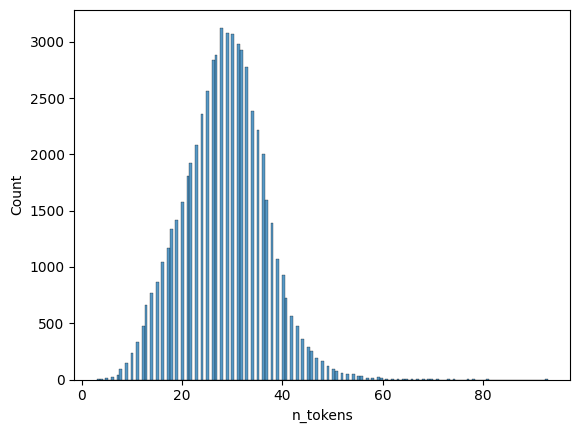

0.95    41.0
0.99    49.0
Name: n_tokens, dtype: float64

In [ ]:
seaborn.histplot(dataset['n_tokens'])
plt.show()

dataset["n_tokens"].quantile([0.95, 0.99])

### Conclusão - Distribuição de Tokens

A análise da distribuição de tokens revela:

| Métrica | Valor | Interpretação |
|---------|-------|---------------|
| **Percentil 95** | ~45 tokens | 95% dos tweets têm até 45 tokens |
| **Percentil 99** | ~55 tokens | Apenas 1% excede 55 tokens |

**Recomendações:**
- `max_length=64` é seguro e cobre >99% dos dados sem truncamento significativo
- `max_length=128` oferece margem extra com overhead mínimo
- Truncamento afetará pouquíssimos tweets, impacto negligenciável no treinamento

---
## Resumo e Próximos Passos

### Principais Descobertas

1. **Tweets são curtos em tokens**: A maioria tem entre 20-50 tokens após tokenização
2. **Tokenizer adequado**: O tokenizer do Twitter-RoBERTa foi treinado em dados similares
3. **Truncamento mínimo**: `max_length=64` ou `128` cobre praticamente todos os casos

### Recomendações para Modelagem

- [ ] Usar `max_length=64` para eficiência ou `max_length=128` para segurança
- [ ] Aplicar padding dinâmico durante treinamento para otimizar batches
- [ ] Considerar `truncation=True` para os poucos outliers